In [64]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio.features import shapes
import rasterio
from shapely.geometry import shape

In [ ]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
rivers_eu = gpd.read_file("../data/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu.shp")
countries = gpd.read_file("../data/world-administrative-boundaries/world-administrative-boundaries.shp")
#flo_IPB = rxr.open_rasterio("../data/flo_IPB_last_date.tif")
with rasterio.open("../data/flo_IPB_last_date.tif") as src:
    data = src.read(1)
    shapes_gen = list(shapes(data, transform=src.transform))
    
geometry = [shape(geom) for geom, val in shapes_gen]
values = [val for geom, val in shapes_gen]
flo_IPB = gpd.GeoDataFrame({'value': values, 'geometry': geometry}, crs=src.crs)


In [20]:
mask_strahler_five = rivers_eu["ORD_STRA"] >= 5
rivers_eu_five = rivers_eu[mask_strahler_five]

<Axes: >

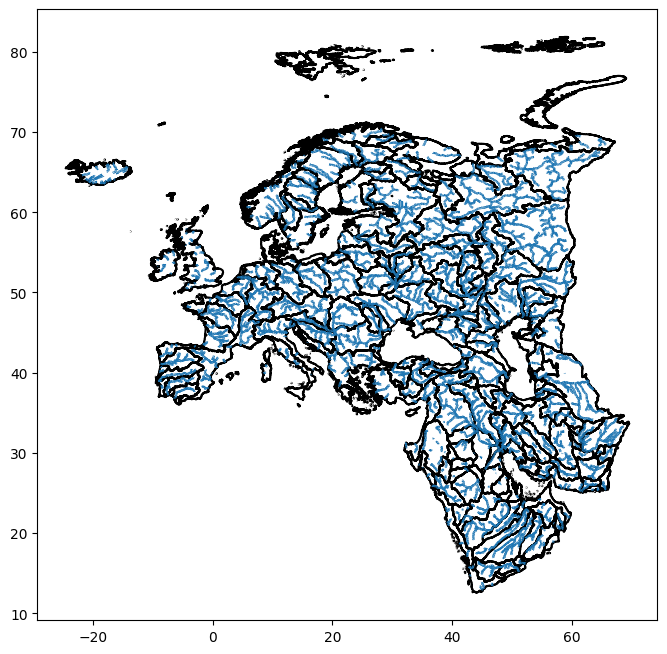

In [ ]:
ax = basins_eu_me.boundary.plot(edgecolor = "k", figsize= (8, 8))
rivers_eu_five.plot(ax = ax);

In [22]:
IPB = basins_eu_me.iloc[45:53]
spain_mask  = countries["English_Nam"] == "Spain" 
portugal_mask = countries["English_Nam"] == "Portugal"
mask_iberia = spain_mask | portugal_mask
iberia = countries[mask_iberia]

In [23]:
rivers_in_IPB = gpd.sjoin(rivers_eu, IPB, predicate='intersects', how='inner')

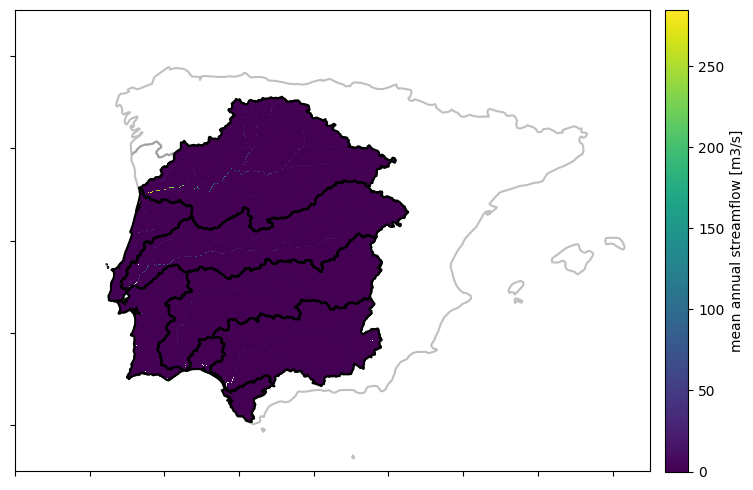

In [57]:
fig, ax = plt.subplots(figsize = (8, 8))
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)
# rivers_in_IPB.plot(ax = ax,linewidth=sizes, alpha = 0.5)
flo_IPB_plot = flo_IPB.where(
    flo_IPB >= 0)
flo_IPB_plot.plot(ax = ax, cbar_kwargs={'shrink': 0.6, 'pad': 0.02})
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k.png", dpi = 200)
plt.show()
plt.close()

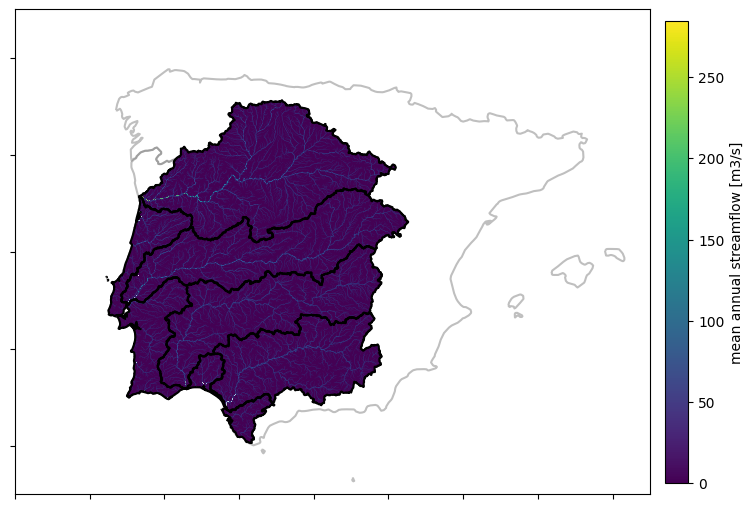

In [56]:
fig, ax = plt.subplots(figsize = (8, 8))
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)
rivers_in_IPB.plot(ax = ax,linewidth=sizes, alpha = 0.5)
flo_IPB_plot = flo_IPB.where(
    flo_IPB >= 0)
flo_IPB_plot.plot(ax = ax, cbar_kwargs={'shrink': 0.6, 'pad': 0.02})
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k_hydrorivers.png", dpi = 200)
plt.show()
plt.close()

In [60]:
flo_IPB

<xarray.DataArray (band: 1, y: 848, x: 970)> Size: 3MB
array([[[-1., -1., ..., -1., -1.],
        [-1., -1., ..., -1., -1.],
        ...,
        [-1., -1., ..., -1., -1.],
        [-1., -1., ..., -1., -1.]]], shape=(1, 848, 970), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
  * x            (x) float64 8kB -9.546 -9.538 -9.529 ... -1.487 -1.479 -1.471
    spatial_ref  int64 8B 0
Attributes:
    description:    mean over the 12 mean monthly streamflow values of the year
    long_name:      mean annual streamflow
    units:          m3/s
    AREA_OR_POINT:  Area
    _FillValue:     -1.0
    scale_factor:   1.0
    add_offset:     0.0

In [61]:
flo_IPB_plot

<xarray.DataArray (band: 1, y: 848, x: 970)> Size: 3MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 848, 970), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 7kB 36.06 36.07 36.08 36.09 ... 43.1 43.11 43.12
  * x            (x) float64 8kB -9.546 -9.538 -9.529 ... -1.487 -1.479 -1.471
    spatial_ref  int64 8B 0
Attributes:
    description:    mean over the 12 mean monthly streamflow values of the year
    long_name:      mean annual streamflow
    units:          m3/s
    AREA_OR_POINT:  Area
    _FillValue:     -1.0
    scale_factor:   1.0
    add_offset:     0.0